In [21]:
import re
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)

DATA_DIR = "data"
WINDOW = 2
MAX_VOCAB = 200000
MIN_COUNT = 2
EMB_DIM = 200
BATCH_SIZE = 1024
EPOCHS_SG = 10
EPOCHS_CBOW = 10
K_NEG = 5

SG_MODE = "train"   # "train" или "load"
CBOW_MODE = "train" # "train" или "load"

SG_CKPT = "skipgram_model.pt"
CBOW_CKPT = "cbow_model.pt"

device: mps


Загрузка исходного теста

In [22]:
from pathlib import Path

def read_all_txt(data_dir: str):
    parts = []
    txt_files = sorted(Path(data_dir).rglob("*.txt"))

    for p in txt_files:
        parts.append(p.read_text(encoding="utf-8", errors="ignore"))

    return "\n".join(parts), txt_files


text, txt_files = read_all_txt(DATA_DIR)

print("txt_files:", len(txt_files))
print("chars:", len(text))
print("preview:", text[:200].replace("\n", " "))

txt_files: 1
chars: 952801
preview: this tale grew in the telling until it became a history of the great war of the ring and included many glimpses of the yet more ancient history that preceded it it was begun soon after the hobbit was 


# Задание 2
сегментируем текст на фрагменты.

In [23]:
_WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def split_sentences(text: str) -> list[str]:
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    if any(ch in text for ch in ".!?"):
        parts = re.split(r"[.!?]+", text)
        parts = [p.strip() for p in parts if p.strip()]
        if parts:
            return parts

    lines = []
    for line in text.split("\n"):
        s = line.strip()
        if s:
            lines.append(s)
    return lines

def tokenize(s: str) -> list[str]:
    return _WORD_RE.findall(s.lower())

sentences = split_sentences(text)
tokenized = [tokenize(s) for s in sentences]
tokenized = [s for s in tokenized if len(s) >= 2]

total_tokens = sum(len(s) for s in tokenized)
freqs = Counter(t for s in tokenized for t in s)

print("sentences:", len(sentences))
print("tokenized_sentences:", len(tokenized))
print("total_tokens:", total_tokens)
print("raw_vocab_size:", len(freqs))

if tokenized:
    print("example:", tokenized[0][:25])
else:
    print("example: []")

print("top10:", freqs.most_common(10))

sentences: 14601
tokenized_sentences: 14321
total_tokens: 187244
raw_vocab_size: 8678
example: ['this', 'tale', 'grew', 'in', 'the', 'telling', 'until', 'it', 'became', 'a', 'history', 'of', 'the', 'great', 'war', 'of']
top10: [('the', 11614), ('and', 7501), ('of', 5025), ('to', 3910), ('a', 3691), ('he', 2992), ('in', 2978), ('it', 2723), ('i', 2723), ('that', 2489)]


In [24]:
def build_vocab(tokenized_sentences, max_vocab=5000, min_count=2):
    cnt = Counter(t for s in tokenized_sentences for t in s)
    items = [(w, c) for w, c in cnt.items() if c >= min_count]
    items.sort(key=lambda x: x[1], reverse=True)

    vocab = ["<UNK>"] + [w for w, _ in items[:max(0, max_vocab - 1)]]
    word2id = {w: i for i, w in enumerate(vocab)}
    id2word = {i: w for i, w in enumerate(vocab)}
    return vocab, word2id, id2word

vocab, word2id, id2word = build_vocab(tokenized, MAX_VOCAB, MIN_COUNT)

unk_id = word2id["<UNK>"]
encoded_sentences = []

for s in tokenized:
    encoded_sentences.append([word2id.get(w, unk_id) for w in s])

unk_tokens = sum(1 for s in encoded_sentences for x in s if x == unk_id)
total_tokens_v = sum(len(s) for s in encoded_sentences)

print("vocab_size:", len(vocab))
print("UNK_id:", unk_id)
print("unk_tokens:", unk_tokens, "| share:", unk_tokens / total_tokens_v if total_tokens_v else 0)

if encoded_sentences:
    print("mapped example ids:", encoded_sentences[0][:25])
    print("mapped example words:", [id2word[i] for i in encoded_sentences[0][:25]])
else:
    print("mapped example ids: []")

print("top10_vocab:", vocab[:10])

vocab_size: 5327
UNK_id: 0
unk_tokens: 3352 | share: 0.01790177522377219
mapped example ids: [46, 417, 292, 7, 1, 1373, 197, 8, 359, 5, 589, 3, 1, 71, 566, 3]
mapped example words: ['this', 'tale', 'grew', 'in', 'the', 'telling', 'until', 'it', 'became', 'a', 'history', 'of', 'the', 'great', 'war', 'of']
top10_vocab: ['<UNK>', 'the', 'and', 'of', 'to', 'a', 'he', 'in', 'it', 'i']


Формирование словаря

In [25]:
def subsample(tokenized_v, t=1e-4):
    cnt = Counter(w for s in tokenized_v for w in s)
    total = sum(cnt.values())
    freqs = {w: c / total for w, c in cnt.items()}

    out = []
    for s in tokenized_v:
        ns = []
        for w in s:
            f = freqs[w]
            p_drop = max(0.0, 1.0 - (t / f) ** 0.5)
            if random.random() > p_drop:
                ns.append(w)
        if len(ns) >= 2:
            out.append(ns)
    return out

encoded_sub = subsample(encoded_sentences, t = 1e-3)

print("before: sentences =", len(encoded_sentences), "tokens =", sum(len(s) for s in encoded_sentences))
print("after : sentences =", len(encoded_sub), "tokens =", sum(len(s) for s in encoded_sub))

before: sentences = 14321 tokens = 187244
after : sentences = 14170 tokens = 119061


In [26]:
def make_skipgram_pairs(encoded_sentences, window=2):
    pairs = []
    for sent in encoded_sentences:
        n = len(sent)
        for i, center in enumerate(sent):
            L = max(0, i - window)
            R = min(n, i + window + 1)
            for j in range(L, R):
                if j == i:
                    continue
                pairs.append((center, sent[j]))
    return np.asarray(pairs, dtype=np.int64)

pairs = make_skipgram_pairs(encoded_sub, window=WINDOW)

print("pairs.shape:", pairs.shape)
for a, b in pairs[:10]:
    print(id2word[int(a)], "->", id2word[int(b)])

pairs.shape: (391224, 2)
this -> tale
this -> grew
tale -> this
tale -> grew
tale -> telling
grew -> this
grew -> tale
grew -> telling
grew -> until
telling -> tale


Подготовка данных для обучения Skip-gram

In [27]:
class SkipGramPairsDataset(Dataset):
    def __init__(self, pairs_np: np.ndarray):
        self.pairs = torch.from_numpy(pairs_np).long()

    def __len__(self):
        return self.pairs.shape[0]

    def __getitem__(self, idx):
        return self.pairs[idx, 0], self.pairs[idx, 1]

sg_ds = SkipGramPairsDataset(pairs)
sg_dl = DataLoader(
    sg_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0
)

print("dataset size:", len(sg_ds))
print("sg batches:", len(sg_dl))

dataset size: 391224
sg batches: 383


# Задание 3
Подготовка negative sampling для Skip-gram

In [28]:
V = len(vocab)

id_counts = torch.zeros(V, dtype=torch.float32)
for sent in encoded_sentences:
    for idx in sent:
        id_counts[idx] += 1

neg_weights = id_counts.pow(0.75)
neg_weights[0] = 0.0
neg_probs = neg_weights / neg_weights.sum()

print("V:", V, "| total_tokens:", int(id_counts.sum().item()))
print("neg_probs sum:", float(neg_probs.sum().item()))

V: 5327 | total_tokens: 187244
neg_probs sum: 1.0000001192092896


Skip-gram модель

In [29]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, emb_dim)
        self.out_embed = nn.Embedding(vocab_size, emb_dim)
        nn.init.uniform_(self.in_embed.weight, -0.5/emb_dim, 0.5/emb_dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, center_ids, pos_ids, neg_ids):
        v = self.in_embed(center_ids)          # (B,D)
        u_pos = self.out_embed(pos_ids)        # (B,D)
        u_neg = self.out_embed(neg_ids)        # (B,K,D)

        pos_score = torch.sum(v * u_pos, dim=1)                 # (B,)
        pos_loss = F.logsigmoid(pos_score)                      # (B,)

        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2) # (B,K)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)          # (B,)

        return -(pos_loss + neg_loss).mean()

sg_model = SkipGramNegSampling(V, EMB_DIM).to(device)
sg_opt = torch.optim.Adam(sg_model.parameters(), lr=2e-3)

neg_probs_dev = neg_probs.to(device)

print("Skip-gram model ready")
print("V:", V, "EMB_DIM:", EMB_DIM)
print("neg_probs device:", neg_probs_dev.device)
print("Skip-gram model ready")

Skip-gram model ready
V: 5327 EMB_DIM: 200
neg_probs device: mps:0
Skip-gram model ready


In [30]:
def save_skipgram(model, path):
    torch.save({
        "vocab_size": V,
        "emb_dim": EMB_DIM,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_skipgram(path, device):
    ckpt = torch.load(path, map_location=device)

    model = SkipGramNegSampling(
        ckpt["vocab_size"],
        ckpt["emb_dim"]
    ).to(device)

    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    return model, ckpt["vocab"], ckpt["word2id"], ckpt["id2word"]

In [31]:
import torch.nn.functional as F

if SG_MODE == "train":
    sg_model = SkipGramNegSampling(V, EMB_DIM).to(device)
    sg_opt = torch.optim.Adam(sg_model.parameters(), lr=2e-3)

    sg_train_loss = []

    for ep in range(1, EPOCHS_SG + 1):
        sg_model.train()
        total_loss = 0.0
        steps = 0

        for center, context in sg_dl:
            center = center.to(device).long()
            context = context.to(device).long()

            neg = torch.multinomial(
                neg_probs_dev,
                num_samples=center.shape[0] * K_NEG,
                replacement=True
            ).view(center.shape[0], K_NEG)

            sg_opt.zero_grad(set_to_none=True)
            loss = sg_model(center, context, neg)
            loss.backward()
            sg_opt.step()

            total_loss += float(loss.item())
            steps += 1

        epoch_loss = total_loss / steps
        sg_train_loss.append(epoch_loss)
        print(f"[SG] epoch {ep}/{EPOCHS_SG} | loss={epoch_loss:.4f}")

    save_skipgram(sg_model, SG_CKPT)
    print("Skip-gram weights saved to", SG_CKPT)

else:
    sg_model, vocab, word2id, id2word = load_skipgram(SG_CKPT, device)
    print("Skip-gram weights loaded from", SG_CKPT)

sg_emb = sg_model.in_embed.weight.detach().cpu().numpy()
np.save("skipgram_embeddings.npy", sg_emb)
print("saved skipgram_embeddings.npy | shape:", sg_emb.shape)

[SG] epoch 1/10 | loss=2.8814
[SG] epoch 2/10 | loss=2.5879
[SG] epoch 3/10 | loss=2.4697
[SG] epoch 4/10 | loss=2.3368
[SG] epoch 5/10 | loss=2.2047
[SG] epoch 6/10 | loss=2.0876
[SG] epoch 7/10 | loss=1.9851
[SG] epoch 8/10 | loss=1.8991
[SG] epoch 9/10 | loss=1.8308
[SG] epoch 10/10 | loss=1.7711
Skip-gram weights saved to skipgram_model.pt
saved skipgram_embeddings.npy | shape: (5327, 200)


# Задание 4
Поиск топ-5 ближайших слов по косинусной мере

In [32]:
sg_emb = np.load("skipgram_embeddings.npy")
sg_emb_n = sg_emb / (np.linalg.norm(sg_emb, axis=1, keepdims=True) + 1e-12)

def topk_cosine(word: str, topk: int = 5):
    w = word.lower()
    if w not in word2id:
        return f"'{word}' нет в словаре"
    
    idx = word2id[w]
    v = sg_emb_n[idx]
    sims = sg_emb_n @ v

    sims[idx] = -1.0
    sims[word2id["<UNK>"]] = -1.0

    best = np.argsort(-sims)[:topk]
    return [(id2word[int(i)], float(sims[int(i)])) for i in best]

print(topk_cosine("ring", 5))
print(topk_cosine("frodo", 5))

[('ding', 0.5276786088943481), ('ruling', 0.511558473110199), ('dong', 0.5008480548858643), ('del', 0.4828425645828247), ('dillo', 0.47582483291625977)]
[('contented', 0.5650675892829895), ('noakes', 0.4309963583946228), ('dreaming', 0.4113173484802246), ('pippin', 0.40676698088645935), ('selling', 0.4065457284450531)]


# Задание 5
Подготовка данных для CBOW

In [33]:
WINDOW_CBOW = 2
unk_id = word2id["<UNK>"]

sent_ids = [[word2id.get(w, unk_id) for w in s] for s in tokenized]

need = 2 * WINDOW_CBOW + 1
sent_ids = [s for s in sent_ids if len(s) >= need]

print("CBOW: window =", WINDOW_CBOW)
print("CBOW: sentences kept =", len(sent_ids), "| need_len >=", need)

if sent_ids:
    print(
        "CBOW: min/avg/max len =",
        min(map(len, sent_ids)),
        sum(map(len, sent_ids)) / len(sent_ids),
        max(map(len, sent_ids))
    )

CBOW: window = 2
CBOW: sentences kept = 13665 | need_len >= 5
CBOW: min/avg/max len = 5 13.555579948774241 20


In [34]:
class CBOWDataset(Dataset):
    def __init__(self, sent_ids, window=2):
        self.sent_ids = sent_ids
        self.window = window
        self.index = []
        w = window

        for si, s in enumerate(sent_ids):
            if len(s) < 2 * w + 1:
                continue
            for i in range(w, len(s) - w):
                self.index.append((si, i))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        si, i = self.index[idx]
        s = self.sent_ids[si]
        w = self.window

        ctx = s[i - w:i] + s[i + 1:i + w + 1]
        target = s[i]

        return torch.tensor(ctx, dtype=torch.long), torch.tensor(target, dtype=torch.long)

cbow_ds = CBOWDataset(sent_ids, window=WINDOW_CBOW)
cbow_dl = DataLoader(
    cbow_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0
)

print("cbow examples:", len(cbow_ds))
print("cbow batches:", len(cbow_dl))

cbow examples: 130577
cbow batches: 128


In [35]:
class CBOW(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, ctx_ids):
        e = self.emb(ctx_ids)     # (B,C,D)
        h = e.mean(dim=1)         # (B,D)
        logits = self.fc(h)       # (B,V)
        return logits

cbow_model = CBOW(V, EMB_DIM).to(device)
cbow_opt = torch.optim.Adam(cbow_model.parameters(), lr=2e-3)

In [36]:
def save_cbow(model, path):
    torch.save({
        "vocab_size": V,
        "emb_dim": EMB_DIM,
        "state_dict": model.state_dict(),
        "vocab": vocab,
        "word2id": word2id,
        "id2word": id2word
    }, path)

def load_cbow(path, device):
    ckpt = torch.load(path, map_location=device)

    model = CBOW(
        ckpt["vocab_size"],
        ckpt["emb_dim"]
    ).to(device)

    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    return model, ckpt["vocab"], ckpt["word2id"], ckpt["id2word"]

Обучение CBOW модели

In [37]:
if CBOW_MODE == "train":
    cbow_model = CBOW(V, EMB_DIM).to(device)
    cbow_opt = torch.optim.Adam(cbow_model.parameters(), lr=2e-3)

    cbow_train_loss = []

    for ep in range(1, EPOCHS_CBOW + 1):
        cbow_model.train()
        total_loss = 0.0
        steps = 0

        for ctx, target in cbow_dl:
            ctx = ctx.to(device).long()
            target = target.to(device).long()

            cbow_opt.zero_grad(set_to_none=True)
            logits = cbow_model(ctx)
            loss = F.cross_entropy(logits, target)
            loss.backward()
            cbow_opt.step()

            total_loss += float(loss.item())
            steps += 1

        epoch_loss = total_loss / steps
        cbow_train_loss.append(epoch_loss)
        print(f"[CBOW] epoch {ep}/{EPOCHS_CBOW} | loss={epoch_loss:.4f}")

    save_cbow(cbow_model, CBOW_CKPT)
    print("CBOW weights saved to", CBOW_CKPT)

else:
    cbow_model, vocab, word2id, id2word = load_cbow(CBOW_CKPT, device)
    print("CBOW weights loaded from", CBOW_CKPT)

cbow_emb = cbow_model.emb.weight.detach().cpu().numpy()
np.save("cbow_embeddings.npy", cbow_emb)
print("saved cbow_embeddings.npy | shape:", cbow_emb.shape)

[CBOW] epoch 1/10 | loss=6.9152
[CBOW] epoch 2/10 | loss=5.6371
[CBOW] epoch 3/10 | loss=5.1963
[CBOW] epoch 4/10 | loss=4.8820
[CBOW] epoch 5/10 | loss=4.6300
[CBOW] epoch 6/10 | loss=4.4169
[CBOW] epoch 7/10 | loss=4.2316
[CBOW] epoch 8/10 | loss=4.0686
[CBOW] epoch 9/10 | loss=3.9249
[CBOW] epoch 10/10 | loss=3.7965
CBOW weights saved to cbow_model.pt
saved cbow_embeddings.npy | shape: (5327, 200)


In [38]:
cbow_emb = np.load("cbow_embeddings.npy")
cbow_emb_n = cbow_emb / (np.linalg.norm(cbow_emb, axis=1, keepdims=True) + 1e-12)

def topk_cosine_cbow(word: str, topk: int = 5):
    w = word.lower()
    if w not in word2id:
        return f"'{word}' нет в словаре"

    idx = word2id[w]
    v = cbow_emb_n[idx]
    sims = cbow_emb_n @ v

    sims[idx] = -1.0
    sims[word2id["<UNK>"]] = -1.0

    best = np.argsort(-sims)[:topk]
    return [(id2word[int(i)], float(sims[int(i)])) for i in best]

print(topk_cosine_cbow("ring", 5))
print(topk_cosine_cbow("frodo", 5))

[('ideas', 0.31987816095352173), ('regions', 0.30179306864738464), ('greenwood', 0.2708154022693634), ('accord', 0.2533608078956604), ('involved', 0.2518124580383301)]
[('comfortably', 0.2503751516342163), ('complete', 0.24734702706336975), ('profound', 0.23599976301193237), ('gl', 0.23414531350135803), ('cling', 0.23125851154327393)]


In [39]:
def predict_cbow(context_words, model, word2id, id2word, topk=5):
    ids = [word2id.get(w.lower(), word2id["<UNK>"]) for w in context_words]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        vals, inds = torch.topk(probs, k=topk, dim=1)

    result = []
    for score, idx in zip(vals[0].cpu().numpy(), inds[0].cpu().numpy()):
        result.append((id2word[int(idx)], float(score)))
    return result

print(predict_cbow(["one", "to", "them", "all"], cbow_model, word2id, id2word, topk=5))

[('bring', 0.05796327069401741), ('at', 0.03628845885396004), ('see', 0.029334520921111107), ('and', 0.02404259517788887), ('after', 0.023524228483438492)]


Визуализация 10–30 самых частых слов

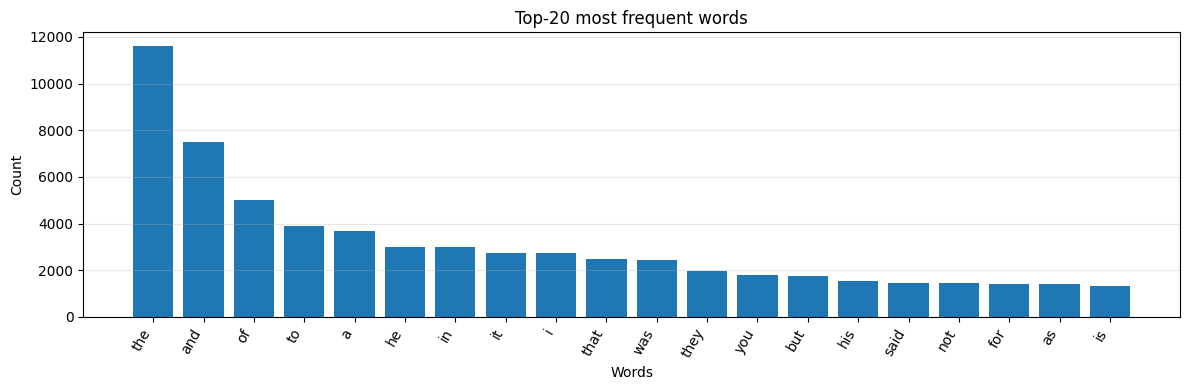

In [40]:
TOPN = min(20, len(freqs))   # 10..30 по ТЗ
top = freqs.most_common(TOPN)

words = [w for w, _ in top]
counts = [c for _, c in top]

plt.figure(figsize=(12, 4))
plt.bar(words, counts)
plt.xticks(rotation=60, ha="right")
plt.title(f"Top-{TOPN} most frequent words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cbow_top_words.png")
plt.show()